In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

In [2]:
pd.set_option('display.max_columns', None) # 제한 없이 출력

In [3]:
df = pd.read_csv("df_cycle_B5671836_NN.csv")

In [4]:
for col in df.columns:
    print(col)

global_cycle
cha_t_cycle
cha_start
cha_time
cha_V_first
cha_V_last
cha_V_diff
cha_V_mean
cha_V_max
cha_V_min
cha_I_first
cha_I_last
cha_I_diff
cha_I_mean
cha_I_max
cha_I_min
cha_V_chg_first
cha_V_chg_last
cha_V_chg_diff
cha_I_chg_first
cha_I_chg_last
cha_I_chg_diff
cha_T_max
cha_T_mean
cha_imp
imp_t_cycle
imp_start
imp_Re
imp_Rct
imp1_Battery_impedance_real
imp1_Battery_impedance_imag
imp1_Battery_impedance_mag
imp_dis
cha_dis
dis_t_cycle
dis_start
dis_time
dis_V_first
dis_V_last
dis_V_diff
dis_V_mean
dis_V_max
dis_V_min
dis_V_load_mean
dis_I_load_mean
dis_I_first
dis_I_last
dis_I_diff
dis_I_mean
dis_I_max
dis_I_min
dis_T_max
dis_T_mean
dis_Capacity
SOH_target
dis_IR_drop
cha_t_cv_start
cha_ratio_cc
dis_dV_dQ_early
RUL
is_EOL
dis_imp2
imp2_t_cycle
imp2_start
imp2_Re
imp2_Rct
dis_cha
imp2_cha
cha_T_first
cha_T_last
cha_T_diff
cha_T_min
dis_T_first
dis_T_last
dis_T_diff
dis_T_min
imp1_Sense_current_real
imp1_Sense_current_imag
imp1_Sense_current_mag
imp1_Battery_current_real
imp1_Battery

In [ ]:
# 배터리 선택 
SELECTED_BATTERIES = ['B0005', 'B0006', 'B0007', 'B0018']


print(f"선택된 배터리: {SELECTED_BATTERIES}")
print(f"전체 배터리:   {df['battery_id'].unique().tolist()}")

# 선택한 배터리만 필터링 
df = df[df['battery_id'].isin(SELECTED_BATTERIES)].copy()
print(f"필터링 후: {len(df)}행")
print(f"\n배터리별 데이터 수:")
print(df['battery_id'].value_counts())

선택된 배터리: ['B0005', 'B0006', 'B0007', 'B0018']
전체 배터리:   ['B0005', 'B0006', 'B0007', 'B0018', 'B0036']
필터링 후: 633행

배터리별 데이터 수:
battery_id
B0005    167
B0006    167
B0007    167
B0018    132
Name: count, dtype: int64


In [ ]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 분석 대상 컬럼 ─────────────────────────────────
targets = {
    '저항/열화': ['dis_dV_dQ_early', 'dis_IR_drop'],
    '충전/방전': ['cha_t_cv_start', 'cha_ratio_cc', 'dis_time'],
    '환경/통계': ['global_cycle', 'dis_T_max', 'cha_T_max',
                 'cha_V_diff', 'dis_V_diff']
}

resist_cols = ['imp_Re', 'imp_Rct']

# ── 상수값 체크 함수 ────────────────────────────────
def is_constant(series):
    return series.dropna().nunique() <= 1

# ── Re / Rct 각각 출력 ───────────────────────────────
results = []

for resist in resist_cols:
    print(f"\n{'='*85}")
    print(f"기준 저항: {resist}")
    print(f"{'='*85}")
    print(f"{'지표':<20} | {'그룹':<8} | {'피어슨':>9} | {'스피어만':>9} | {'켄달타우':>9} | 비고")
    print(f"{'-'*85}")

    for group_name, cols in targets.items():
        for col in cols:
            tmp = df[[resist, col]].dropna()

            # 데이터 부족 체크
            if len(tmp) < 10:
                print(f"{col:<20} | {group_name:<8} | "
                      f"데이터 부족 ({len(tmp)}개)")
                continue

            # 상수값 체크
            if is_constant(tmp[resist]) or is_constant(tmp[col]):
                print(f"{col:<20} | {group_name:<8} | "
                      f"상수값 → 제외 (unique: {tmp[col].nunique()}개)")
                continue

            r_p, p_p = stats.pearsonr(tmp[resist], tmp[col])
            r_s, p_s = stats.spearmanr(tmp[resist], tmp[col])
            r_k, p_k = stats.kendalltau(tmp[resist], tmp[col])

            sig_p = "✅" if p_p < 0.05 else "❌"
            sig_s = "✅" if p_s < 0.05 else "❌"
            sig_k = "✅" if p_k < 0.05 else "❌"
            note  = "📈 비선형!" if abs(r_s) - abs(r_p) > 0.05 else ""

            print(f"{col:<20} | {group_name:<8} | "
                  f"{sig_p}{r_p:>+7.3f} | "
                  f"{sig_s}{r_s:>+8.3f} | "
                  f"{sig_k}{r_k:>+8.3f} | {note}")

            results.append({
                'resist':      resist,
                'group':       group_name,
                'feature':     col,
                'r_pearson':   round(r_p, 3),
                'r_spearman':  round(r_s, 3),
                'r_kendall':   round(r_k, 3),
                'p_spearman':  round(p_s, 4),
                'significant': p_s < 0.05,
                'nonlinear':   abs(r_s) - abs(r_p) > 0.05
            })

result_df = pd.DataFrame(results)


🔋 기준 저항: imp_Re
지표                   | 그룹       |       피어슨 |      스피어만 |      켄달타우 | 비고
-------------------------------------------------------------------------------------
dis_dV_dQ_early      | 저항/열화    | ✅ +0.801 | ✅  +0.751 | ✅  +0.594 | 
dis_IR_drop          | 저항/열화    | ✅ -0.320 | ✅  -0.372 | ✅  -0.243 | 📈 비선형!
cha_t_cv_start       | 충전/방전    | ⚠️ 상수값 → 제외 (unique: 1개)
cha_ratio_cc         | 충전/방전    | ⚠️ 상수값 → 제외 (unique: 1개)
dis_time             | 충전/방전    | ✅ -0.543 | ✅  -0.506 | ✅  -0.373 | 
global_cycle         | 환경/통계    | ✅ +0.482 | ✅  +0.433 | ✅  +0.322 | 
dis_T_max            | 환경/통계    | ✅ +0.173 | ✅  +0.118 | ✅  +0.115 | 
cha_T_max            | 환경/통계    | ✅ +0.138 | ❌  +0.040 | ✅  +0.065 | 
cha_V_diff           | 환경/통계    | ❌ -0.054 | ✅  -0.419 | ✅  -0.330 | 📈 비선형!
dis_V_diff           | 환경/통계    | ✅ +0.610 | ✅  +0.589 | ✅  +0.444 | 

🔋 기준 저항: imp_Rct
지표                   | 그룹       |       피어슨 |      스피어만 |      켄달타우 | 비고
-------------------------------------------

- cha_t_cv_start → ⚠️ 상수값 → 제외 (unique: 1개)
- cha_ratio_cc   → ⚠️ 상수값 → 제외 (unique: 1개)

In [7]:
# 살펴보기
# ══════════════════════════════════════════════════════
# STEP 1. 문제 확인 — cha_t_cv_start, cha_ratio_cc 실제 값 보기
# ══════════════════════════════════════════════════════

print("=== STEP 1. 문제 컬럼 실제 값 확인 ===")
print()

cols_check = ['cha_t_cv_start', 'cha_ratio_cc']

for col in cols_check:
    print(f"[{col}]")
    print(f"  unique 값 개수: {df[col].nunique()}")
    print(f"  unique 값들:    {df[col].unique()}")
    print(f"  상위 5개:")
    print(df[col].head())
    print()

# 결과: 전부 0.0 → 상수값이라 상관계수 계산 불가

=== STEP 1. 문제 컬럼 실제 값 확인 ===

[cha_t_cv_start]
  unique 값 개수: 1
  unique 값들:    [0.]
  상위 5개:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: cha_t_cv_start, dtype: float64

[cha_ratio_cc]
  unique 값 개수: 1
  unique 값들:    [0.]
  상위 5개:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: cha_ratio_cc, dtype: float64



In [8]:
# ══════════════════════════════════════════════════════
# STEP 2. 왜 0.0인지 파악
# — 이 컬럼들이 뭘 의미하는지 먼저 이해
# ══════════════════════════════════════════════════════

print("=== STEP 2. 컬럼 의미 파악 ===")
print()
print("cha_t_cv_start = 충전 중 CC→CV 전환이 시작되는 시점 (초)")
print("cha_ratio_cc   = 전체 충전 시간 중 CC 구간 비율 (0~1)")
print()
print("CC→CV 전환 원리:")
print("  충전 시작 → 전류 일정(CC) → 전압 4.18V 도달 → 전압 고정(CV)")
print("  전압이 4.18V에 도달하는 시점 = CC→CV 전환 시점")
print()
print("→ df_cycle CSV 생성 시 이 계산이 안 됐음 → 전부 0.0")

=== STEP 2. 컬럼 의미 파악 ===

cha_t_cv_start = 충전 중 CC→CV 전환이 시작되는 시점 (초)
cha_ratio_cc   = 전체 충전 시간 중 CC 구간 비율 (0~1)

CC→CV 전환 원리:
  충전 시작 → 전류 일정(CC) → 전압 4.18V 도달 → 전압 고정(CV)
  전압이 4.18V에 도달하는 시점 = CC→CV 전환 시점

→ df_cycle CSV 생성 시 이 계산이 안 됐음 → 전부 0.0


In [9]:
# ══════════════════════════════════════════════════════
# STEP 3. battery_all_integrated 원본에서
#         실제로 전압이 4.18V에 도달하는지 확인
# ══════════════════════════════════════════════════════

print("=== STEP 3. 원본 데이터에서 CV 전환 가능한지 확인 ===")
print()

df_raw = pd.read_csv('battery_all_integrated.csv', low_memory=False)
df_raw['Voltage_measured'] = pd.to_numeric(df_raw['Voltage_measured'], errors='coerce')
df_raw['Time']             = pd.to_numeric(df_raw['Time'],             errors='coerce')

# 충전 구간만
cha_raw = df_raw[df_raw['type'] == 'charge']

# 4.18V 이상 도달한 행 수 확인
cv_rows = cha_raw[cha_raw['Voltage_measured'] >= 4.18]

print(f"전체 충전 행:            {len(cha_raw):>10,}개")
print(f"4.18V 이상 도달한 행:    {len(cv_rows):>10,}개")
print(f"CV 전환 가능 비율:        {len(cv_rows)/len(cha_raw)*100:.1f}%")
print()

# B0005 cycle 1 샘플 확인
sample = cha_raw[(cha_raw['battery_id'] == 'B0005') & (cha_raw['cycle'] == 1)]
print("B0005 cycle 1 충전 전압 분포:")
print(sample['Voltage_measured'].describe())
print()
print(f"→ 4.18V 이상 행: {len(sample[sample['Voltage_measured'] >= 4.18])}개")

=== STEP 3. 원본 데이터에서 CV 전환 가능한지 확인 ===

전체 충전 행:             1,903,329개
4.18V 이상 도달한 행:     1,452,481개
CV 전환 가능 비율:        76.3%

B0005 cycle 1 충전 전압 분포:
count    789.000000
mean       4.187420
std        0.045794
min        3.479394
25%        4.190885
50%        4.205710
75%        4.206481
max        4.209949
Name: Voltage_measured, dtype: float64

→ 4.18V 이상 행: 623개


In [10]:
# ══════════════════════════════════════════════════════
# STEP 4. 실제로 재계산해보기 (B0005 cycle 1 샘플)
# ══════════════════════════════════════════════════════

print("=== STEP 4. 샘플 1개로 재계산 테스트 ===")
print()

sample = cha_raw[
    (cha_raw['battery_id'] == 'B0005') &
    (cha_raw['cycle'] == 1)
].sort_values('Time')

total_time = sample['Time'].max()
cv_start_rows = sample[sample['Voltage_measured'] >= 4.18]

if len(cv_start_rows) > 0:
    cv_start   = cv_start_rows['Time'].iloc[0]   # CC→CV 전환 시점
    ratio_cc   = cv_start / total_time            # CC 비율
    ratio_cv   = 1 - ratio_cc                     # CV 비율
else:
    cv_start = total_time
    ratio_cc = 1.0
    ratio_cv = 0.0

print(f"총 충전 시간:        {total_time:.1f}초 ({total_time/60:.1f}분)")
print(f"CC→CV 전환 시점:     {cv_start:.1f}초 ({cv_start/60:.1f}분)")
print(f"CC 구간 비율:        {ratio_cc:.3f} ({ratio_cc*100:.1f}%)")
print(f"CV 구간 비율:        {ratio_cv:.3f} ({ratio_cv*100:.1f}%)")
print()
print(f"→ 0.0이 아닌 실제 값이 계산됨! ✅")

=== STEP 4. 샘플 1개로 재계산 테스트 ===

총 충전 시간:        7597.9초 (126.6분)
CC→CV 전환 시점:     546.6초 (9.1분)
CC 구간 비율:        0.072 (7.2%)
CV 구간 비율:        0.928 (92.8%)

→ 0.0이 아닌 실제 값이 계산됨! ✅


In [11]:
# ══════════════════════════════════════════════════════
# STEP 5. 전체 배터리 전체 cycle 재계산
# ══════════════════════════════════════════════════════

print("=== STEP 5. 전체 재계산 ===")
print()

cv_results = []

for (bid, cyc), group in cha_raw.groupby(['battery_id', 'cycle']):
    group      = group.sort_values('Time')
    total_time = group['Time'].max()
    cv_rows    = group[group['Voltage_measured'] >= 4.18]

    if len(cv_rows) > 0 and total_time > 0:
        cv_start  = cv_rows['Time'].iloc[0]
        ratio_cc  = cv_start / total_time
        ratio_cv  = 1 - ratio_cc
    else:
        cv_start = total_time
        ratio_cc = 1.0
        ratio_cv = 0.0

    cv_results.append({
        'battery_id':     bid,
        'global_cycle':          cyc,
        'cha_t_cv_start': cv_start,
        'cha_ratio_cc':   ratio_cc,
        'cv_ratio':       ratio_cv,
        'cc_time_min':    cv_start / 60
    })

cv_df = pd.DataFrame(cv_results)

print(f"재계산 완료: {len(cv_df)}행")
print()
print("재계산 후 unique 값 수:")
print(f"  cha_t_cv_start: {cv_df['cha_t_cv_start'].nunique()}개  ← 0에서 변함!")
print(f"  cha_ratio_cc:   {cv_df['cha_ratio_cc'].nunique()}개  ← 0에서 변함!")
print()
print(cv_df.head(5))

=== STEP 5. 전체 재계산 ===

재계산 완료: 644행

재계산 후 unique 값 수:
  cha_t_cv_start: 634개  ← 0에서 변함!
  cha_ratio_cc:   636개  ← 0에서 변함!

  battery_id  global_cycle  cha_t_cv_start  cha_ratio_cc  cv_ratio  \
0      B0005             1         546.610      0.071942  0.928058   
1      B0005             2        3117.406      0.296444  0.703556   
2      B0005             3        3114.672      0.297073  0.702927   
3      B0005             4        3094.468      0.297605  0.702395   
4      B0005             5        3104.484      0.295800  0.704200   

   cc_time_min  
0     9.110167  
1    51.956767  
2    51.911200  
3    51.574467  
4    51.741400  


In [12]:
# ══════════════════════════════════════════════════════
# STEP 6. df에 재계산값 업데이트 후 재확인
# ══════════════════════════════════════════════════════

print("=== STEP 6. df 업데이트 및 결과 확인 ===")
print()

# 기존 0.0 컬럼 제거 후 재계산값으로 교체
df_fixed = df.drop(columns=['cha_t_cv_start', 'cha_ratio_cc'], errors='ignore')
df_fixed = df_fixed.merge(
    cv_df[['battery_id', 'global_cycle', 'cha_t_cv_start', 'cha_ratio_cc', 'cv_ratio', 'cc_time_min']],
    on=['battery_id', 'global_cycle'],
    how='left'
)

print("업데이트 전 vs 후:")
print(f"  cha_t_cv_start unique: 1개 → {df_fixed['cha_t_cv_start'].nunique()}개")
print(f"  cha_ratio_cc   unique: 1개 → {df_fixed['cha_ratio_cc'].nunique()}개")
print()

# 다시 상관분석 돌리기
from scipy import stats

for col in ['cha_t_cv_start', 'cha_ratio_cc']:
    tmp = df_fixed[['imp_Re', col]].dropna()
    r_s, p_s = stats.spearmanr(tmp['imp_Re'], tmp[col])
    sig = "✅ 유의" if p_s < 0.05 else "❌ 비유의"
    print(f"{col}: 스피어만 r={r_s:+.3f}, p={p_s:.4f} → {sig}")

# 이후 df를 df_fixed로 교체
df = df_fixed
print()
print("→ df 업데이트 완료! 이제 상관분석에 정상적으로 사용 가능 ✅")

=== STEP 6. df 업데이트 및 결과 확인 ===

업데이트 전 vs 후:
  cha_t_cv_start unique: 1개 → 625개
  cha_ratio_cc   unique: 1개 → 627개

cha_t_cv_start: 스피어만 r=-0.682, p=0.0000 → ✅ 유의
cha_ratio_cc: 스피어만 r=-0.674, p=0.0000 → ✅ 유의

→ df 업데이트 완료! 이제 상관분석에 정상적으로 사용 가능 ✅


In [13]:
# ══════════════════════════════════════════════════════
# 저항 vs 충/방전 지표 전체 상관분석
# ══════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 분석 대상 ─────────────────────────────────────────
resist_cols = ['imp_Re', 'imp_Rct']

targets = {
    '저항/열화': ['dis_dV_dQ_early', 'dis_IR_drop'],
    '충전/방전': ['cha_t_cv_start', 'cha_ratio_cc', 'dis_time'],
    '환경/통계': ['global_cycle', 'dis_T_max', 'cha_T_max',
                 'cha_V_diff', 'dis_V_diff']
}

# ── 상수값 체크 함수 ────────────────────────────────────
def is_constant(series):
    return series.dropna().nunique() <= 1

# ── 상관분석 실행 ──────────────────────────────────────
results = []

for resist in resist_cols:
    print(f"\n{'='*85}")
    print(f"🔋 기준 저항: {resist}")
    print(f"{'='*85}")
    print(f"{'지표':<22} | {'그룹':<8} | {'피어슨':>9} | {'스피어만':>9} | {'켄달타우':>9} | 비고")
    print(f"{'-'*85}")

    for group_name, cols in targets.items():
        for col in cols:

            # 컬럼 존재 확인
            if col not in df.columns:
                print(f"{col:<22} | {group_name:<8} | ⚠️ 컬럼 없음")
                continue

            tmp = df[[resist, col]].dropna()

            # 데이터 부족 체크
            if len(tmp) < 10:
                print(f"{col:<22} | {group_name:<8} | "
                      f"⚠️ 데이터 부족 ({len(tmp)}개)")
                continue

            # 상수값 체크
            if is_constant(tmp[resist]) or is_constant(tmp[col]):
                print(f"{col:<22} | {group_name:<8} | "
                      f"⚠️ 상수값 제외 (unique: {tmp[col].nunique()}개)")
                continue

            r_p, p_p = stats.pearsonr(tmp[resist],  tmp[col])
            r_s, p_s = stats.spearmanr(tmp[resist], tmp[col])
            r_k, p_k = stats.kendalltau(tmp[resist], tmp[col])

            sig_p = "✅" if p_p < 0.05 else "❌"
            sig_s = "✅" if p_s < 0.05 else "❌"
            sig_k = "✅" if p_k < 0.05 else "❌"
            note  = "📈 비선형!" if abs(r_s) - abs(r_p) > 0.05 else ""

            print(f"{col:<22} | {group_name:<8} | "
                  f"{sig_p}{r_p:>+7.3f} | "
                  f"{sig_s}{r_s:>+8.3f} | "
                  f"{sig_k}{r_k:>+8.3f} | {note}")

            results.append({
                'resist':      resist,
                'group':       group_name,
                'feature':     col,
                'r_pearson':   round(r_p, 3),
                'r_spearman':  round(r_s, 3),
                'r_kendall':   round(r_k, 3),
                'p_spearman':  round(p_s, 4),
                'significant': p_s < 0.05,
                'nonlinear':   abs(r_s) - abs(r_p) > 0.05
            })

result_df = pd.DataFrame(results)


🔋 기준 저항: imp_Re
지표                     | 그룹       |       피어슨 |      스피어만 |      켄달타우 | 비고
-------------------------------------------------------------------------------------
dis_dV_dQ_early        | 저항/열화    | ✅ +0.801 | ✅  +0.751 | ✅  +0.594 | 
dis_IR_drop            | 저항/열화    | ✅ -0.320 | ✅  -0.372 | ✅  -0.243 | 📈 비선형!
cha_t_cv_start         | 충전/방전    | ✅ -0.693 | ✅  -0.682 | ✅  -0.540 | 
cha_ratio_cc           | 충전/방전    | ✅ -0.690 | ✅  -0.674 | ✅  -0.529 | 
dis_time               | 충전/방전    | ✅ -0.543 | ✅  -0.506 | ✅  -0.373 | 
global_cycle           | 환경/통계    | ✅ +0.482 | ✅  +0.433 | ✅  +0.322 | 
dis_T_max              | 환경/통계    | ✅ +0.173 | ✅  +0.118 | ✅  +0.115 | 
cha_T_max              | 환경/통계    | ✅ +0.138 | ❌  +0.040 | ✅  +0.065 | 
cha_V_diff             | 환경/통계    | ❌ -0.054 | ✅  -0.419 | ✅  -0.330 | 📈 비선형!
dis_V_diff             | 환경/통계    | ✅ +0.610 | ✅  +0.589 | ✅  +0.444 | 

🔋 기준 저항: imp_Rct
지표                     | 그룹       |       피어슨 |      스피어만 |      켄달타우 | 

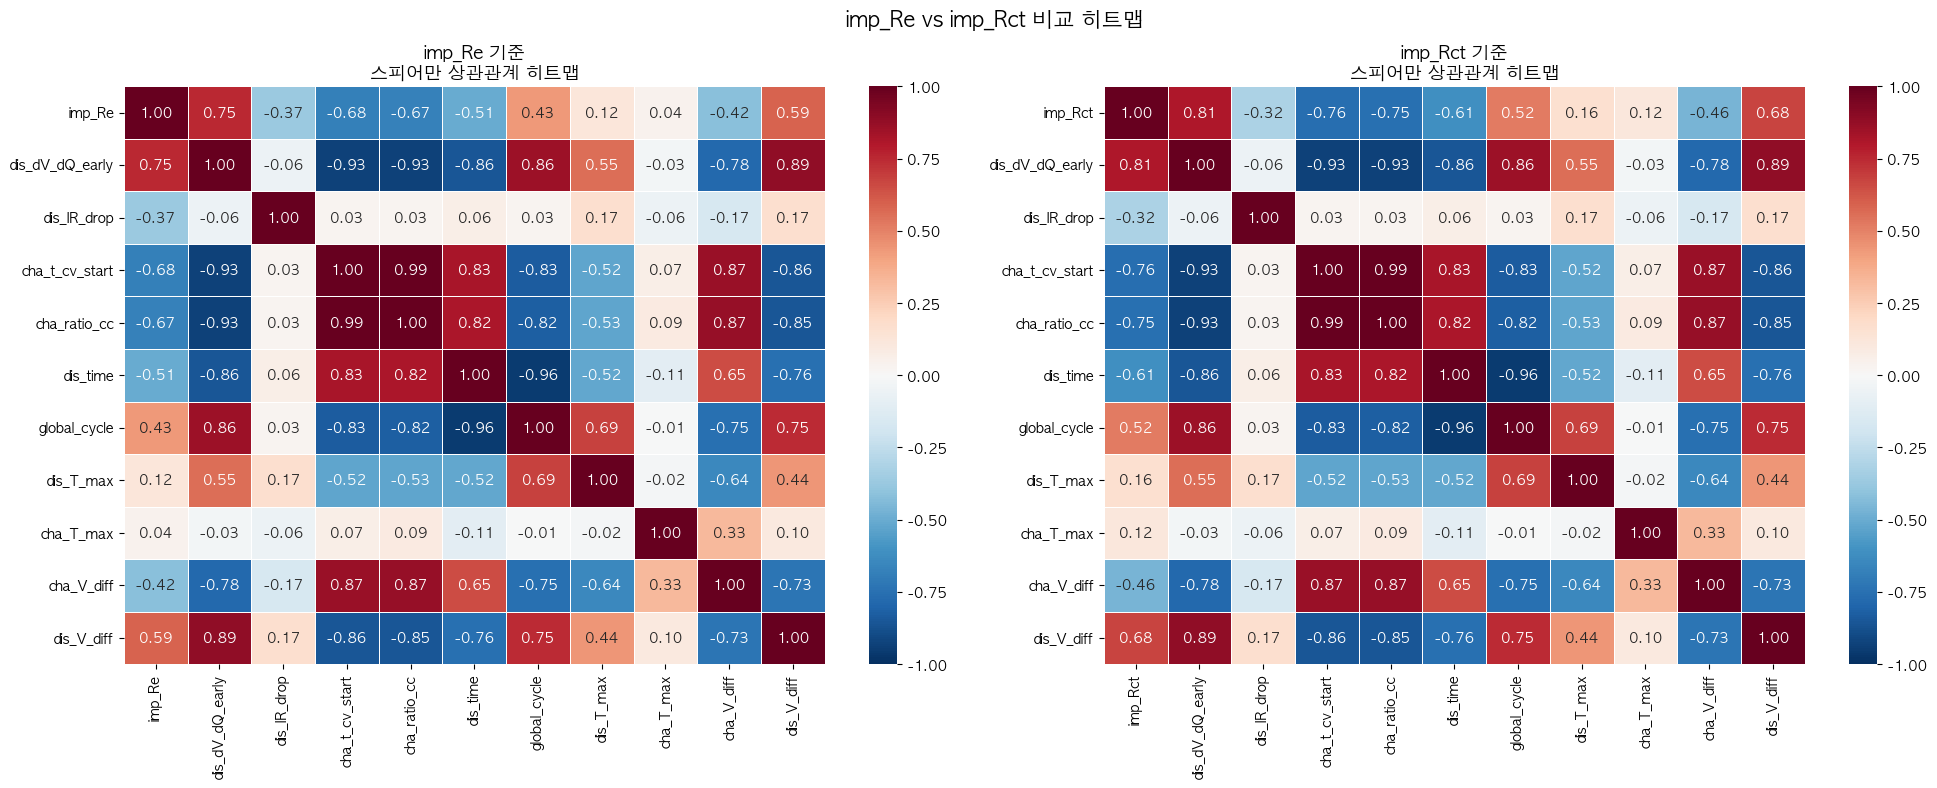

In [ ]:
# ── 히트맵 (Re / Rct) ──────────────────────────
valid_cols = [col for cols in targets.values()
              for col in cols
              if col in df.columns and not is_constant(df[col])]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, resist in zip(axes, resist_cols):
    corr_cols   = [resist] + valid_cols
    corr_matrix = df[corr_cols].corr(method='spearman')

    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.2f',
        cmap='RdBu_r', center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f'{resist} 기준\n스피어만 상관관계 히트맵', fontsize=13)

plt.suptitle('imp_Re vs imp_Rct 비교 히트맵', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ── Re vs Rct 결과 비교 요약표 ────────────────────────
print("\n" + "=" * 70)
print("📊 Re vs Rct 핵심 지표 비교 (스피어만 |r| > 0.3 & p < 0.05)")
print("=" * 70)
print(f"{'지표':<22} | {'그룹':<8} | {'Re r':>8} | {'Rct r':>8} | 차이 | 비고")
print("-" * 70)

re_df  = result_df[result_df['resist'] == 'imp_Re'].set_index('feature')
rct_df = result_df[result_df['resist'] == 'imp_Rct'].set_index('feature')

for feat in result_df['feature'].unique():
    re_r  = re_df.loc[feat,  'r_spearman'] if feat in re_df.index  else np.nan
    rct_r = rct_df.loc[feat, 'r_spearman'] if feat in rct_df.index else np.nan
    group = re_df.loc[feat, 'group'] if feat in re_df.index else ''

    max_r = max(abs(re_r)  if not np.isnan(re_r)  else 0,
                abs(rct_r) if not np.isnan(rct_r) else 0)

    if max_r >= 0.3:
        re_sig  = "✅" if not np.isnan(re_r)  and abs(re_r)  >= 0.3 else "  "
        rct_sig = "✅" if not np.isnan(rct_r) and abs(rct_r) >= 0.3 else "  "
        diff    = abs(abs(re_r) - abs(rct_r)) if not (np.isnan(re_r) or np.isnan(rct_r)) else np.nan
        diff_mark = "🔺" if not np.isnan(diff) and diff > 0.05 else ""

        print(f"{feat:<22} | {group:<8} | "
              f"{re_sig}{re_r:>+6.3f} | "
              f"{rct_sig}{rct_r:>+6.3f} | "
              f"{diff:>4.3f} | {diff_mark}")


📊 Re vs Rct 핵심 지표 비교 (스피어만 |r| > 0.3 & p < 0.05)
지표                     | 그룹       |     Re r |    Rct r | 차이 | 비고
----------------------------------------------------------------------
dis_dV_dQ_early        | 저항/열화    | ✅+0.751 | ✅+0.810 | 0.059 | 🔺
dis_IR_drop            | 저항/열화    | ✅-0.372 | ✅-0.318 | 0.054 | 🔺
cha_t_cv_start         | 충전/방전    | ✅-0.682 | ✅-0.761 | 0.079 | 🔺
cha_ratio_cc           | 충전/방전    | ✅-0.674 | ✅-0.754 | 0.080 | 🔺
dis_time               | 충전/방전    | ✅-0.506 | ✅-0.611 | 0.105 | 🔺
global_cycle           | 환경/통계    | ✅+0.433 | ✅+0.519 | 0.086 | 🔺
cha_V_diff             | 환경/통계    | ✅-0.419 | ✅-0.463 | 0.044 | 
dis_V_diff             | 환경/통계    | ✅+0.589 | ✅+0.677 | 0.088 | 🔺


In [17]:
# ── 최종 핵심 지표 순위 (Re 기준) ─────────────────────
print("\n" + "=" * 55)
print("🏆 최종 핵심 저항 요인 순위 (Re 기준, 스피어만 |r| 내림차순)")
print("=" * 55)

top = (result_df[
    (result_df['resist']     == 'imp_Re') &
    (result_df['significant'] == True)
].sort_values('r_spearman', key=abs, ascending=False))

print(f"{'순위':<4} | {'지표':<22} | {'그룹':<8} | {'r':>8} | 비고")
print("-" * 55)
for rank, (_, row) in enumerate(top.iterrows(), 1):
    nl = "📈 비선형" if row['nonlinear'] else ""
    print(f"{rank:<4} | {row['feature']:<22} | "
          f"{row['group']:<8} | "
          f"{row['r_spearman']:>+8.3f} | {nl}")


🏆 최종 핵심 저항 요인 순위 (Re 기준, 스피어만 |r| 내림차순)
순위   | 지표                     | 그룹       |        r | 비고
-------------------------------------------------------
1    | dis_dV_dQ_early        | 저항/열화    |   +0.751 | 
2    | cha_t_cv_start         | 충전/방전    |   -0.682 | 
3    | cha_ratio_cc           | 충전/방전    |   -0.674 | 
4    | dis_V_diff             | 환경/통계    |   +0.589 | 
5    | dis_time               | 충전/방전    |   -0.506 | 
6    | global_cycle           | 환경/통계    |   +0.433 | 
7    | cha_V_diff             | 환경/통계    |   -0.419 | 📈 비선형
8    | dis_IR_drop            | 저항/열화    |   -0.372 | 📈 비선형
9    | dis_T_max              | 환경/통계    |   +0.118 | 


### 열화 구간의 추이 살펴보기

In [ ]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── cycle 기준 구간 3개 ───────────────────────────────
zone_a = df[(df['global_cycle'] >= 20) & (df['global_cycle'] < 40)]
zone_b = df[(df['global_cycle'] >= 40) & (df['global_cycle'] < 60)]
zone_c = df[(df['global_cycle'] >= 60) & (df['global_cycle'] < 80)]

zones       = [zone_a, zone_b, zone_c]
zone_names  = ['cycle 20~40', 'cycle 40~60', 'cycle 60~80']
zone_colors = ['#FFA500', '#FF6347', '#DC143C']

features = ['cha_t_cv_start', 'dis_time', 'dis_T_max']
labels   = ['CC→CV 전환(초)', '방전시간(초)', '방전온도(°C)']

bid_colors = {
    'B0005': 'steelblue', 'B0006': 'orange',
    'B0007': 'green',     'B0018': 'crimson'
}

# ── 데이터 수 확인 ────────────────────────────────────
print('=== cycle 구간별 데이터 수 ===')
for zone, name in zip(zones, zone_names):
    print(f'{name}: {len(zone)}개')
    print(f'  배터리별: {zone["battery_id"].value_counts().to_dict()}')
    print(f'  Rct 평균: {zone["imp_Rct"].mean():.4f}')
    print(f'  SOH 평균: {zone["SOH_target"].mean():.1f}%')
print()

=== cycle 구간별 데이터 수 ===
cycle 20~40: 77개
  배터리별: {'B0018': 20, 'B0005': 19, 'B0006': 19, 'B0007': 19}
  Rct 평균: 0.0747
  SOH 평균: 94.9%
cycle 40~60: 78개
  배터리별: {'B0005': 20, 'B0006': 20, 'B0007': 20, 'B0018': 18}
  Rct 평균: 0.0772
  SOH 평균: 91.0%
cycle 60~80: 80개
  배터리별: {'B0005': 20, 'B0006': 20, 'B0007': 20, 'B0018': 20}
  Rct 평균: 0.0811
  SOH 평균: 84.2%



In [45]:
# ── 기울기 계산 ───────────────────────────────────────
print('=== cycle 구간별 기울기 ===')
print(f'{"지표":<18} | {"cycle 20~40":>12} | {"cycle 40~60":>12} | {"cycle 60~80":>12}')
print('-' * 65)

slope_results = {}

for feat, label in zip(features, labels):
    slopes = []
    for zone in zones:
        tmp = zone[['global_cycle', feat]].dropna()
        if len(tmp) < 5:
            slopes.append(np.nan)
            continue
        model = LinearRegression().fit(tmp[['global_cycle']], tmp[feat])
        slopes.append(model.coef_[0])
    slope_results[feat] = slopes
    print(f'{label:<18} | {slopes[0]:>+12.4f} | {slopes[1]:>+12.4f} | {slopes[2]:>+12.4f}')

=== cycle 구간별 기울기 ===
지표                 |  cycle 20~40 |  cycle 40~60 |  cycle 60~80
-----------------------------------------------------------------
CC→CV 전환(초)        |     -24.7630 |     -10.2568 |     -23.1778
방전시간(초)            |      -7.4942 |      -3.7888 |      -7.3006
방전온도(°C)           |      -0.0093 |      +0.0501 |      +0.0242


/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fit

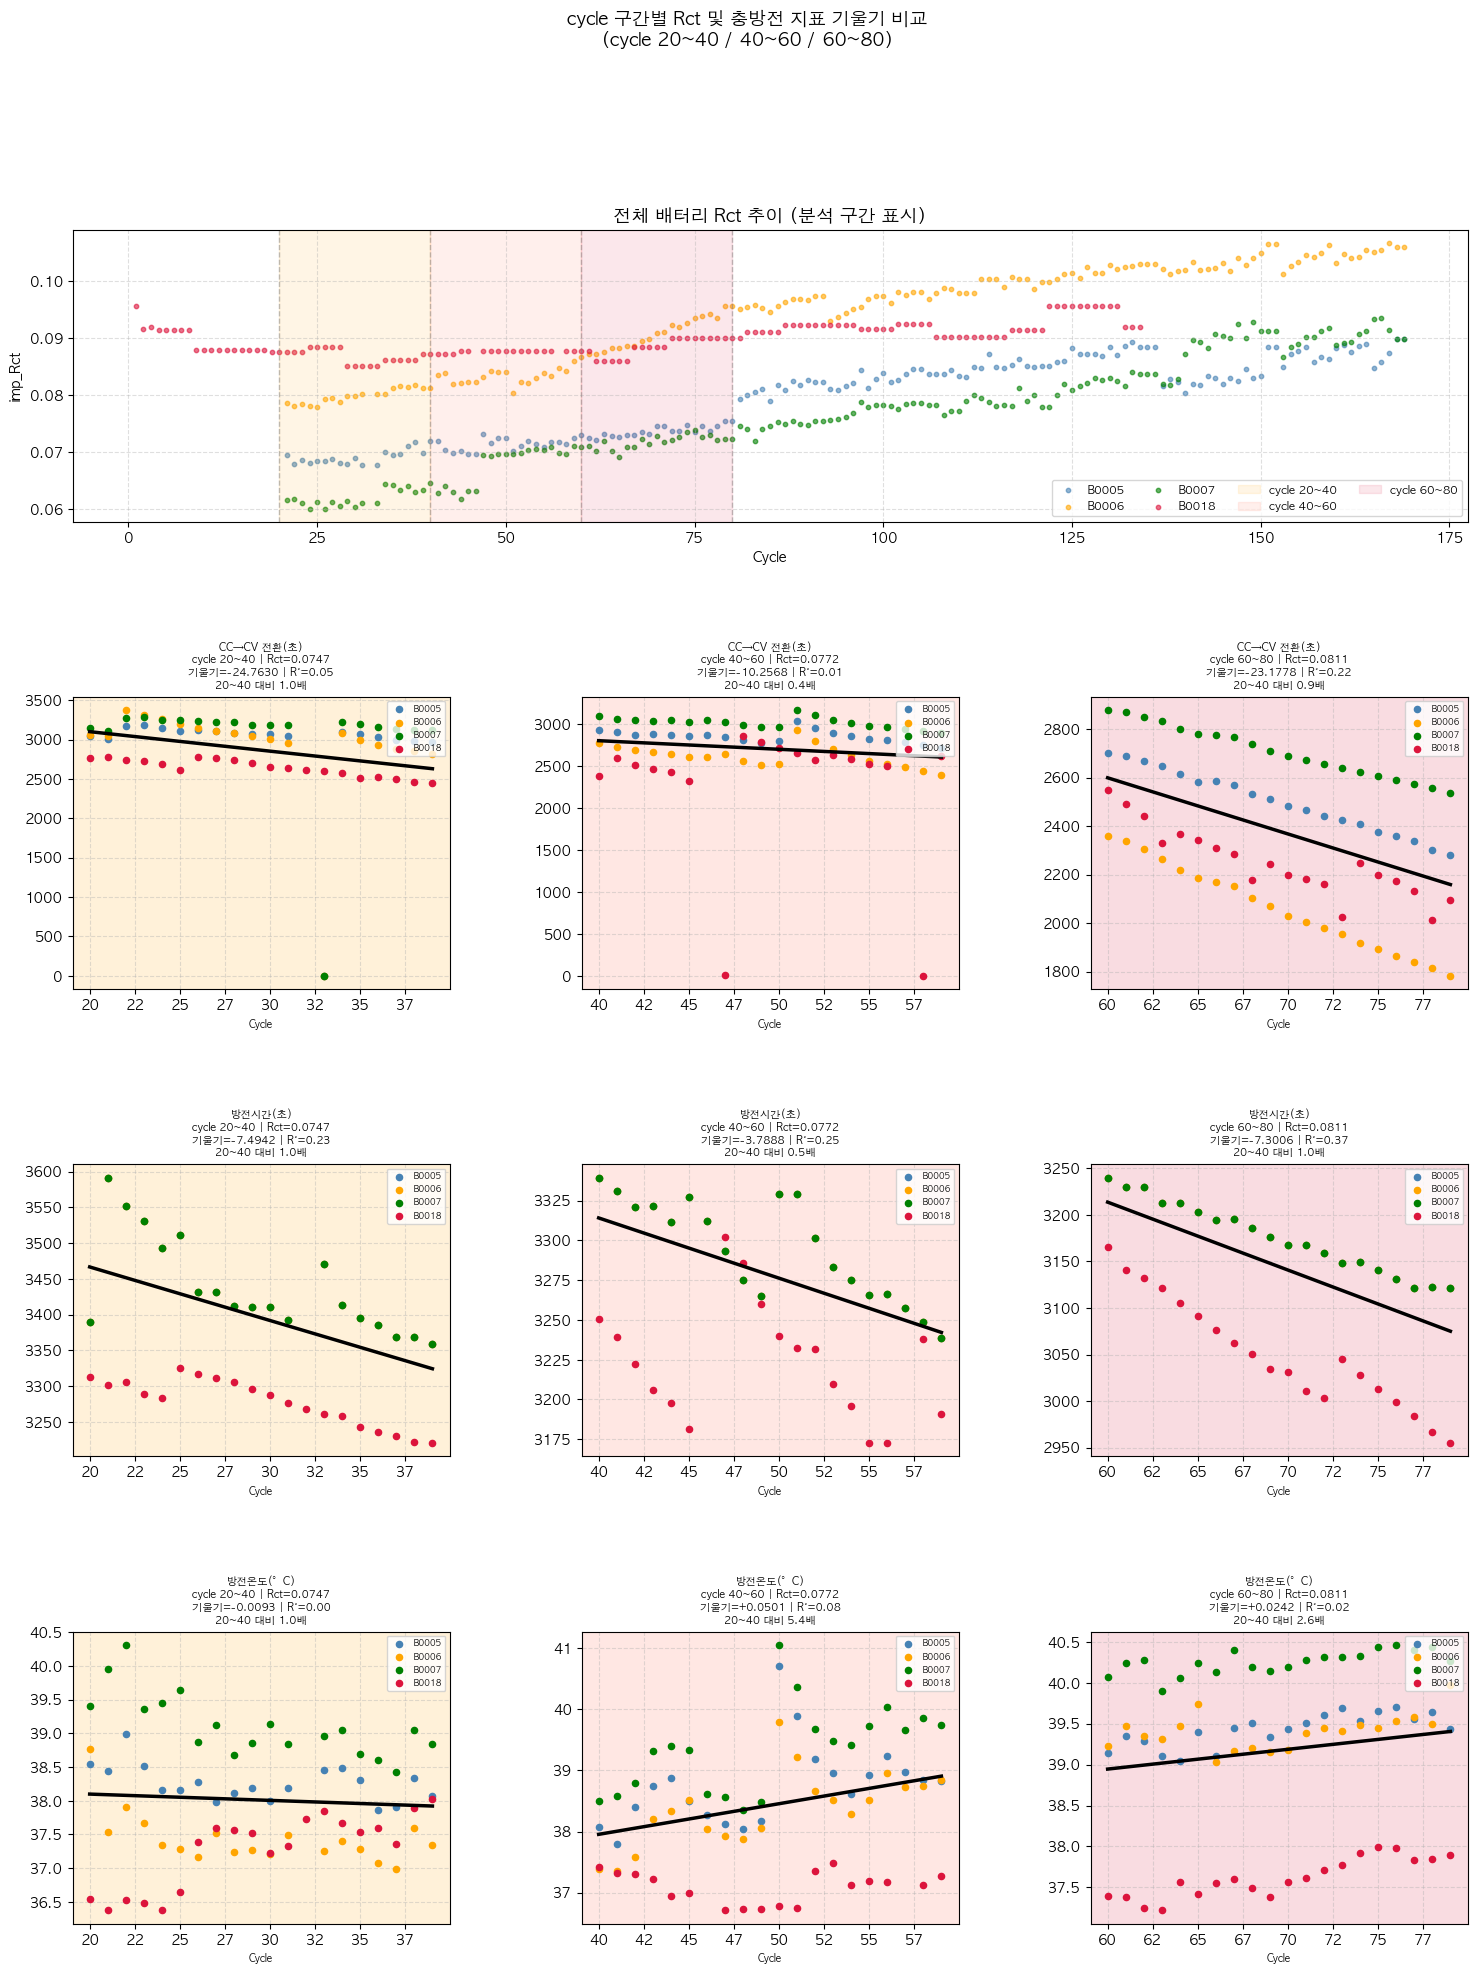

In [58]:
# ── 시각화 ────────────────────────────────────────────

# 행: features 3개 + 상단 Rct 1개 = 총 4행
# 열: 구간 3개
fig = plt.figure(figsize=(18, 22))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.6, wspace=0.35)

# ══════════════════════════════════════════════════════
# 0행: Rct 전체 추이 (3열 전부 차지)
# ══════════════════════════════════════════════════════
ax_top = fig.add_subplot(gs[0, :])

for bid in df['battery_id'].unique():
    sub = df[df['battery_id'] == bid].sort_values('global_cycle')
    ax_top.scatter(sub['global_cycle'], sub['imp_Rct'],
                   s=10, color=bid_colors.get(bid, 'gray'),
                   alpha=0.6, label=bid)

ax_top.axvspan(20, 40, alpha=0.10, color='orange', label='cycle 20~40')
ax_top.axvspan(40, 60, alpha=0.10, color='tomato', label='cycle 40~60')
ax_top.axvspan(60, 80, alpha=0.10, color='crimson', label='cycle 60~80')
for x in [20, 40, 60, 80]:
    ax_top.axvline(x=x, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax_top.set_title('전체 배터리 Rct 추이 (분석 구간 표시)', fontsize=13)
ax_top.set_xlabel('Cycle')
ax_top.set_ylabel('imp_Rct')
ax_top.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
ax_top.legend(fontsize=8, ncol=4)
ax_top.grid(True, linestyle='--', alpha=0.4)

# ══════════════════════════════════════════════════════
# 1~3행: 지표 × 구간 서브플롯
# ══════════════════════════════════════════════════════
for row_idx, (feat, label) in enumerate(zip(features, labels)):
    for col_idx, (zone, zname, zcolor) in enumerate(
            zip(zones, zone_names, zone_colors)):

        ax  = fig.add_subplot(gs[row_idx + 1, col_idx])
        tmp = zone[['global_cycle', feat, 'battery_id']].dropna()

        if len(tmp) < 5:
            ax.text(0.5, 0.5, '데이터 부족',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{label}\n{zname}', fontsize=9)
            continue

        # ── 배경색 (patch.set_alpha 제거!) ────────────
        ax.set_facecolor(zcolor)          # 배경색
        ax.patch.set_alpha(0.15)          # 배경만 투명하게

        # ── 배터리별 scatter ───────────────────────────
        for bid in tmp['battery_id'].unique():
            sub_bid = tmp[tmp['battery_id'] == bid]
            ax.scatter(sub_bid['global_cycle'], sub_bid[feat],
                       s=20,
                       color=bid_colors.get(bid, 'gray'),
                       alpha=1.0,         # ← 점은 완전 불투명
                       label=bid,
                       zorder=3)

        # ── 추세선 ────────────────────────────────────
        model  = LinearRegression().fit(tmp[['global_cycle']], tmp[feat])
        x_line = np.linspace(tmp['global_cycle'].min(),
                              tmp['global_cycle'].max(), 100)
        y_line = model.predict(x_line.reshape(-1, 1))
        ax.plot(x_line, y_line,
                color='black', linewidth=2.5, zorder=5)

        slope    = model.coef_[0]
        r2       = model.score(tmp[['global_cycle']], tmp[feat])
        rct_mean = zone['imp_Rct'].mean()

        base  = slope_results[feat][0]
        ratio = abs(slope) / abs(base) if (base and not np.isnan(base)) else 1.0

        ax.set_title(
            f'{label}\n{zname} | Rct={rct_mean:.4f}\n'
            f'기울기={slope:+.4f} | R²={r2:.2f}\n'
            f'20~40 대비 {ratio:.1f}배',
            fontsize=7.5
        )
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
        ax.set_xlabel('Cycle', fontsize=7)
        ax.grid(True, linestyle='--', alpha=0.4, zorder=0)

        # ── 범례 모든 서브플롯에 표시 ─────────────────
        ax.legend(fontsize=6,
                  loc='upper right',
                  framealpha=0.8)          # ← col_idx 조건 제거!
                  
plt.suptitle(
    'cycle 구간별 Rct 및 충방전 지표 기울기 비교\n'
    '(cycle 20~40 / 40~60 / 60~80)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('cycle_zone_rct_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


구간이 넘어가는 곳 그래프로 살펴보기


In [59]:
# ══════════════════════════════════════════════════════
# [추가] 경계 구간 포함 5구간 분석
# 20~40 / 30~50 / 40~60 / 50~70 / 60~80
# ══════════════════════════════════════════════════════
import matplotlib.ticker as ticker

# ── 5구간 정의 ────────────────────────────────────────
zone_a  = df[(df['global_cycle'] >= 20) & (df['global_cycle'] < 40)]
zone_ab = df[(df['global_cycle'] >= 30) & (df['global_cycle'] < 50)]
zone_b  = df[(df['global_cycle'] >= 40) & (df['global_cycle'] < 60)]
zone_bc = df[(df['global_cycle'] >= 50) & (df['global_cycle'] < 70)]
zone_c  = df[(df['global_cycle'] >= 60) & (df['global_cycle'] < 80)]

zones      = [zone_a, zone_ab, zone_b, zone_bc, zone_c]
zone_names = ['20~40', '30~50\n(경계)', '40~60', '50~70\n(경계)', '60~80']
zone_colors = ['#4C96D7', '#7BC8A4', '#FFA500', '#FF8C69', '#DC143C']

features = ['cha_t_cv_start', 'dis_time', 'dis_T_max']
labels   = ['CC→CV 전환(초)', '방전시간(초)', '방전온도(°C)']

bid_colors = {
    'B0005': '#4C72B0', 'B0006': '#FFA500',
    'B0007': '#2CA02C', 'B0018': '#D62728'
}

# ── 구간별 기울기 계산 ────────────────────────────────
print('=== 5구간 기울기 비교 ===')
print(f'{"지표":<16} | {"20~40":>8} | {"30~50":>8} | {"40~60":>8} | {"50~70":>8} | {"60~80":>8}')
print('-' * 70)

slope_results_5 = {}
for feat, label in zip(features, labels):
    slopes = []
    for zone in zones:
        tmp = zone[['global_cycle', feat]].dropna()
        if len(tmp) < 5:
            slopes.append(np.nan)
            continue
        model = LinearRegression().fit(tmp[['global_cycle']], tmp[feat])
        slopes.append(model.coef_[0])
    slope_results_5[feat] = slopes
    print(f'{label:<16} | {slopes[0]:>+8.3f} | {slopes[1]:>+8.3f} | '
          f'{slopes[2]:>+8.3f} | {slopes[3]:>+8.3f} | {slopes[4]:>+8.3f}')

=== 5구간 기울기 비교 ===
지표               |    20~40 |    30~50 |    40~60 |    50~70 |    60~80
----------------------------------------------------------------------
CC→CV 전환(초)      |  -24.763 |   +5.588 |  -10.257 |  -24.992 |  -23.178
방전시간(초)          |   -7.494 |   -6.111 |   -3.789 |   -8.262 |   -7.301
방전온도(°C)         |   -0.009 |   +0.005 |   +0.050 |   +0.012 |   +0.024


/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/Users/300phrnaver.com/Desktop/bootcamp/project3/sparta_project_3_team11/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fit

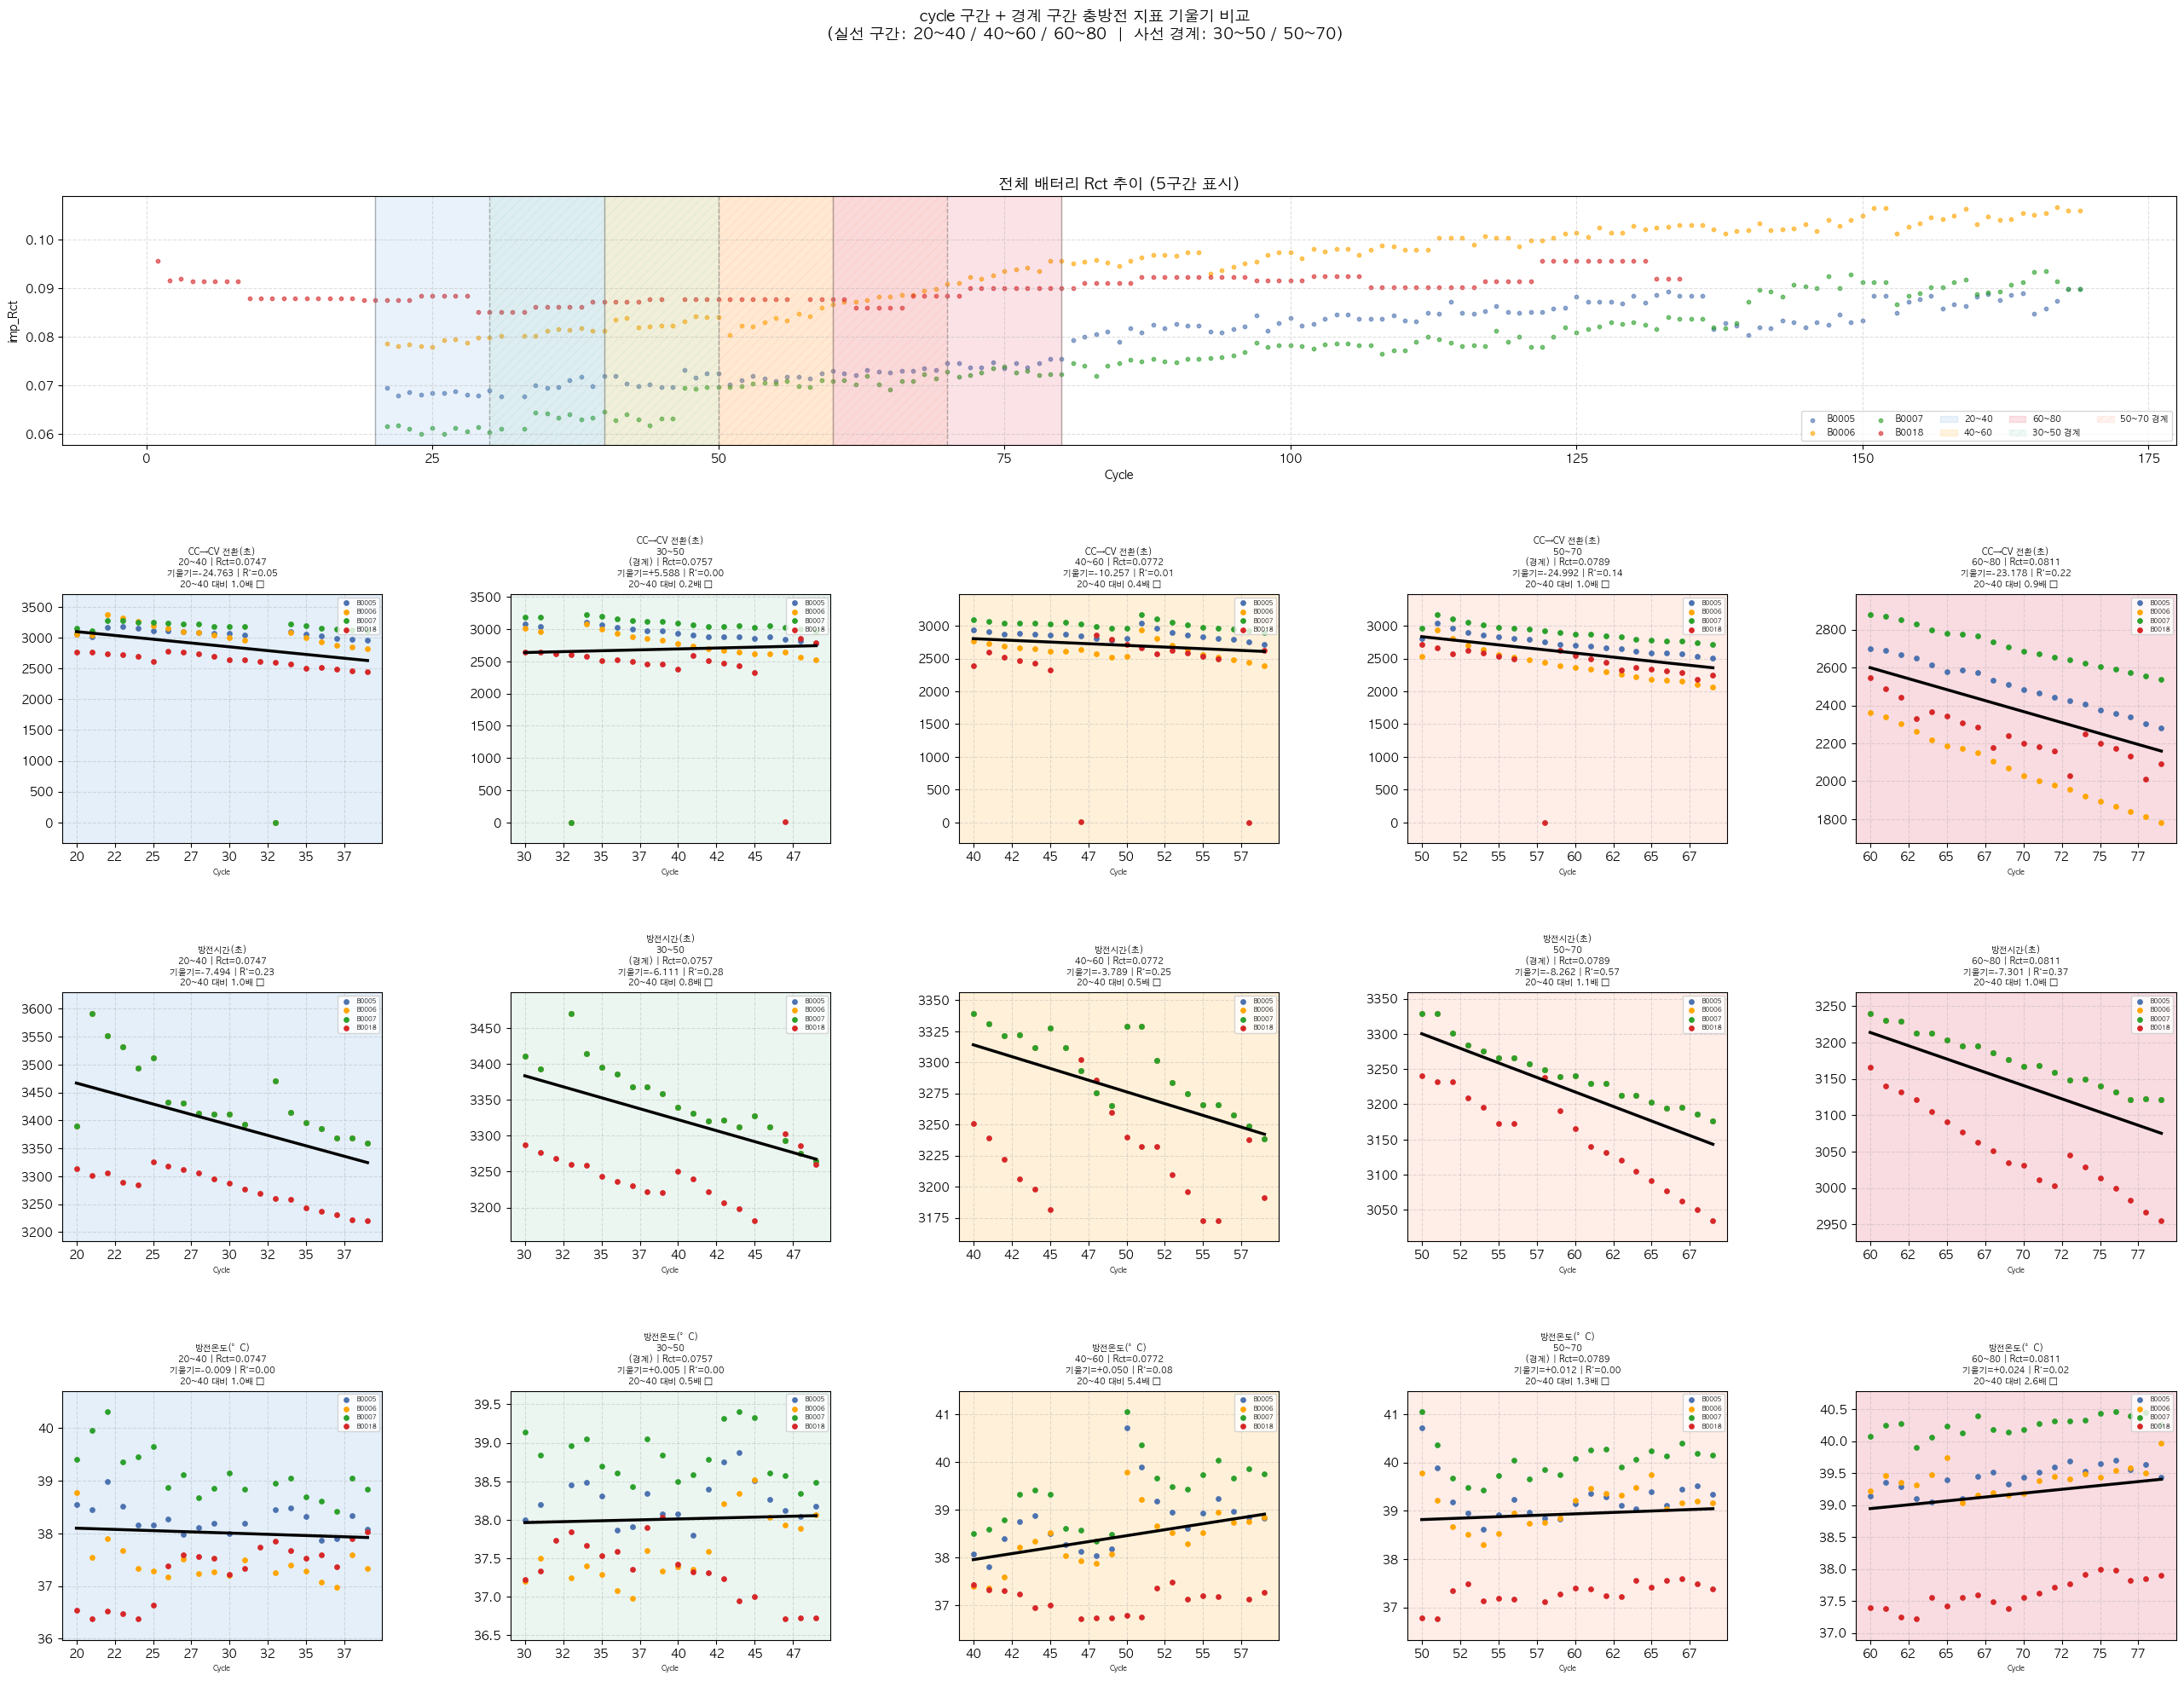

In [64]:
# ── 시각화 ────────────────────────────────────────────
fig = plt.figure(figsize=(32, 22))
gs  = gridspec.GridSpec(4, 5, figure=fig, hspace=0.6, wspace=0.4)

# ── 0행: Rct 전체 추이 + 5구간 표시 ──────────────────
ax_top = fig.add_subplot(gs[0, :])

for bid in df['battery_id'].unique():
    sub = df[df['battery_id'] == bid].sort_values('global_cycle')
    ax_top.scatter(sub['global_cycle'], sub['imp_Rct'],
                   s=10, color=bid_colors.get(bid, 'gray'),
                   alpha=0.6, label=bid)

# 기본 구간 색칠
ax_top.axvspan(20, 40, alpha=0.12, color='#4C96D7', label='20~40')
ax_top.axvspan(40, 60, alpha=0.12, color='#FFA500', label='40~60')
ax_top.axvspan(60, 80, alpha=0.12, color='#DC143C', label='60~80')

# 경계 구간 사선 패턴
ax_top.axvspan(30, 50, alpha=0.10, color='#7BC8A4',
               hatch='///', label='30~50 경계')
ax_top.axvspan(50, 70, alpha=0.10, color='#FF8C69',
               hatch='///', label='50~70 경계')

# 구간 경계선
for x, ls in zip([20, 30, 40, 50, 60, 70, 80],
                  ['-', '--', '-', '--', '-', '--', '-']):
    ax_top.axvline(x=x, color='gray', linestyle=ls,
                   linewidth=1, alpha=0.6)

ax_top.set_title('전체 배터리 Rct 추이 (5구간 표시)', fontsize=13)
ax_top.set_xlabel('Cycle')
ax_top.set_ylabel('imp_Rct')
ax_top.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
ax_top.legend(fontsize=7, ncol=5)
ax_top.grid(True, linestyle='--', alpha=0.4)

# ── 1~3행: 지표 × 5구간 서브플롯 ─────────────────────
for row_idx, (feat, label) in enumerate(zip(features, labels)):
    for col_idx, (zone, zname, zcolor) in enumerate(
            zip(zones, zone_names, zone_colors)):

        ax  = fig.add_subplot(gs[row_idx + 1, col_idx])
        tmp = zone[['global_cycle', feat, 'battery_id']].dropna()

        if len(tmp) < 5:
            ax.text(0.5, 0.5, '데이터 부족',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{label}\n{zname}', fontsize=9)
            continue

        ax.set_facecolor(zcolor)
        ax.patch.set_alpha(0.15)

        # scatter
        for bid in tmp['battery_id'].unique():
            sub_bid = tmp[tmp['battery_id'] == bid]
            ax.scatter(sub_bid['global_cycle'], sub_bid[feat],
                       s=15, color=bid_colors.get(bid, 'gray'),
                       alpha=1.0, label=bid, zorder=3)

        # y축 범위를 데이터 기준으로 여유있게 설정
        y_min = tmp[feat].min()
        y_max = tmp[feat].max()
        margin = (y_max - y_min) * 0.1
        ax.set_ylim(y_min - margin, y_max + margin)  

        # 추세선
        model  = LinearRegression().fit(tmp[['global_cycle']], tmp[feat])
        x_line = np.linspace(tmp['global_cycle'].min(),
                              tmp['global_cycle'].max(), 100)
        y_line = model.predict(x_line.reshape(-1, 1))
        ax.plot(x_line, y_line,
                color='black', linewidth=2.5, zorder=5)

        slope    = model.coef_[0]
        r2       = model.score(tmp[['global_cycle']], tmp[feat])
        rct_mean = zone['imp_Rct'].mean()

        # 20~40 대비 배수
        base  = slope_results_5[feat][0]
        ratio = abs(slope) / abs(base) if (base and not np.isnan(base)) else 1.0
        steep = '🔴' if ratio > 1.5 else '🟢'

        ax.set_title(
            f'{label}\n{zname} | Rct={rct_mean:.4f}\n'
            f'기울기={slope:+.3f} | R²={r2:.2f}\n'
            f'20~40 대비 {ratio:.1f}배 {steep}',
            fontsize=7
        )
        ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
        ax.set_xlabel('Cycle', fontsize=6)
        ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax.legend(fontsize=5, loc='upper right', framealpha=0.8)

plt.suptitle(
    'cycle 구간 + 경계 구간 충방전 지표 기울기 비교\n'
    '(실선 구간: 20~40 / 40~60 / 60~80  |  사선 경계: 30~50 / 50~70)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('cycle_5zone_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
